# All Model Comparison

Notebook ini menggabungkan hasil eksperimen dari baseline original, pruning, low-rank, PTQ, dynamic quantization, QAT, dan QAT dynamic.

Aturan utama:
- Baseline hanya dimasukkan sekali dari `saved_models_original`.
- `Size (KB)` dihitung ulang dari file pipeline langsung jika file tersedia: feature extractor/TFLite + SVM + scaler.
- Untuk pruning, ukuran yang dipakai adalah GZIP pipeline size dari `comparison_table.json`, karena folder saved tidak menyimpan file `.gz`.
- `Compression Rate` dihitung ulang terhadap baseline original: `baseline_size / model_size`.
- `Recall` memakai nilai `Sensitivity` dari notebook eksperimen.


In [1]:
from pathlib import Path
from datetime import datetime
import json
import math
import os
from numbers import Real
from statistics import mean

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


## Configuration

Folder sumber dibuat fixed agar hasil perbandingan mengacu ke eksperimen yang sama.


In [2]:
ROOT = Path.cwd()

FOLDERS = {
    "original": ROOT / "saved_models_original",
    "pruning": ROOT / "saved_models_pruning_20260606_233059",
    "lowrank": ROOT / "saved_models_lowrank_20260606_235704",
    "ptq": ROOT / "saved_models_ptq_20260608_200513",
    "dynamic": ROOT / "saved_models_dynamic_quant_20260608_203225",
    "qat": ROOT / "saved_models_qat_20260606_170334",
    "qat_dynamic": ROOT / "saved_models_qat_dynamic_20260608_205807",
}

OUTPUT_DIR = ROOT / f"comparison_all_models_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Output folder: {OUTPUT_DIR}")


Output folder: d:\bintang\skripsi 0606\comparison_all_models_20260608_213651


## Helper Functions


In [3]:
def read_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def get_size_kb(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file for size calculation: {path}")
    return path.stat().st_size / 1024


def pipeline_size_kb(*paths):
    return sum(get_size_kb(p) for p in paths)


def parse_float(value):
    if value is None:
        return math.nan
    if isinstance(value, Real):
        return float(value)
    text = str(value).strip().replace(",", "")
    for suffix in ["x", "%", "KB", "ms"]:
        text = text.replace(suffix, "")
    text = text.strip()
    if text in {"", "-", "nan", "NaN", "None"}:
        return math.nan
    return float(text)


def mean_or_value(value):
    if isinstance(value, list):
        return float(mean(value))
    return parse_float(value)


def metric_from_row(row, key, fallback_key=None):
    if key in row:
        return parse_float(row[key])
    if fallback_key and fallback_key in row:
        return parse_float(row[fallback_key])
    return math.nan


def make_record(method, model, size_kb, metrics, source_folder, size_source):
    baseline = BASELINE_SIZE_KB
    return {
        "Method": method,
        "Model": model,
        "Size (KB)": float(size_kb),
        "Compression Rate": float(baseline / size_kb) if size_kb and size_kb > 0 else math.nan,
        "Accuracy": metric_from_row(metrics, "Accuracy", "accuracy"),
        "Recall": metric_from_row(metrics, "Sensitivity", "sensitivity"),
        "Specificity": metric_from_row(metrics, "Specificity", "specificity"),
        "Precision": metric_from_row(metrics, "Precision", "precision"),
        "F1-Score": metric_from_row(metrics, "F1-Score", "f1"),
        "AUC": metric_from_row(metrics, "AUC", "auc"),
        "Source Folder": str(source_folder),
        "Size Source": size_source,
    }


def validate_folders():
    missing = [name for name, path in FOLDERS.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing source folders: {missing}")
    print("All source folders found.")

validate_folders()


All source folders found.


## Load Baseline Original

Baseline size dihitung dari pipeline inference asli: `feature_extractor.keras + svm_classifier.pkl + feature_scaler.pkl`.


In [4]:
orig_dir = FOLDERS["original"]
orig_metrics = read_json(orig_dir / "evaluation_metrics.json")

BASELINE_SIZE_KB = pipeline_size_kb(
    orig_dir / "feature_extractor.keras",
    orig_dir / "svm_classifier.pkl",
    orig_dir / "feature_scaler.pkl",
)

baseline_record = {
    "Method": "Original",
    "Model": orig_metrics.get("label", "Original (CNN+Attn+SVM)"),
    "Size (KB)": float(BASELINE_SIZE_KB),
    "Compression Rate": 1.0,
    "Accuracy": parse_float(orig_metrics.get("accuracy")),
    "Recall": mean_or_value(orig_metrics.get("sensitivity")),
    "Specificity": mean_or_value(orig_metrics.get("specificity")),
    "Precision": mean_or_value(orig_metrics.get("precision")),
    "F1-Score": mean_or_value(orig_metrics.get("f1")),
    "AUC": parse_float(orig_metrics.get("auc_macro", orig_metrics.get("auc"))),
    "Source Folder": str(orig_dir),
    "Size Source": "feature_extractor.keras + svm_classifier.pkl + feature_scaler.pkl",
}

print(f"Baseline size: {BASELINE_SIZE_KB:.2f} KB")


Baseline size: 6454.70 KB


## Load Compression Results

Baseline rows inside method folders are skipped, because baseline original has already been added once.


In [5]:
records = [baseline_record]

# Pruning: use GZIP pipeline size from comparison_table.json because saved folder does not contain .gz files.
pruning_dir = FOLDERS["pruning"]
pruning_rows = read_json(pruning_dir / "comparison_table.json")
for row in pruning_rows:
    model = row.get("Model", "")
    if "baseline" in model.lower():
        continue
    size_kb = parse_float(row.get("GZIP (KB)", row.get("Size (KB)")))
    records.append(make_record(
        "Pruning",
        model,
        size_kb,
        row,
        pruning_dir,
        "GZIP (KB) from pruning comparison_table.json",
    ))

# Low-rank: recompute direct pipeline size from each rank folder.
lowrank_dir = FOLDERS["lowrank"]
lowrank_rows = read_json(lowrank_dir / "comparison_table.json")
for row in lowrank_rows:
    model = row.get("Model", "")
    if "baseline" in model.lower():
        continue
    rank = str(row.get("Rank", "")).strip()
    rank_dir = lowrank_dir / f"rank_{rank}"
    size_kb = pipeline_size_kb(
        rank_dir / f"extractor_r{rank}.keras",
        rank_dir / f"svm_classifier_r{rank}.pkl",
        rank_dir / f"scaler_r{rank}.pkl",
    )
    records.append(make_record(
        "Low-Rank",
        model,
        size_kb,
        row,
        lowrank_dir,
        f"rank_{rank}/extractor + svm + scaler",
    ))


def add_tflite_method(method_name, folder_key, file_map):
    folder = FOLDERS[folder_key]
    rows = read_json(folder / "comparison_table.json")
    for row in rows:
        model = row.get("Model", "")
        if "baseline" in model.lower():
            continue
        if model not in file_map:
            raise KeyError(f"No file mapping for model '{model}' in {folder}")
        tflite_file, svm_file, scaler_file = file_map[model]
        size_kb = pipeline_size_kb(folder / tflite_file, folder / svm_file, folder / scaler_file)
        records.append(make_record(
            method_name,
            model,
            size_kb,
            row,
            folder,
            f"{tflite_file} + {svm_file} + {scaler_file}",
        ))

add_tflite_method(
    "PTQ",
    "ptq",
    {
        "FP16": ("extractor_fp16.tflite", "svm_fp16.pkl", "scaler_fp16.pkl"),
        "INT8": ("extractor_int8.tflite", "svm_int8.pkl", "scaler_int8.pkl"),
    },
)

add_tflite_method(
    "Dynamic Quantization",
    "dynamic",
    {
        "FP16 Dynamic": ("extractor_fp16_dynamic.tflite", "svm_fp16.pkl", "scaler_fp16.pkl"),
        "INT8 Dynamic": ("extractor_int8_dynamic.tflite", "svm_int8.pkl", "scaler_int8.pkl"),
    },
)

add_tflite_method(
    "QAT",
    "qat",
    {
        "QAT INT8": ("qat_int8.tflite", "svm_int8.pkl", "scaler_int8.pkl"),
        "QAT FP16": ("qat_fp16.tflite", "svm_fp16.pkl", "scaler_fp16.pkl"),
    },
)

add_tflite_method(
    "QAT Dynamic",
    "qat_dynamic",
    {
        "QAT FP16 Dynamic": ("qat_dynamic_fp16.tflite", "svm_fp16.pkl", "scaler_fp16.pkl"),
        "QAT INT8 Dynamic": ("qat_dynamic_int8.tflite", "svm_int8.pkl", "scaler_int8.pkl"),
    },
)

print(f"Loaded {len(records)} model rows.")


Loaded 21 model rows.


## Combined Comparison Table


In [6]:
df_all = pd.DataFrame(records)

metric_cols = ["Accuracy", "Recall", "Specificity", "Precision", "F1-Score", "AUC"]
for col in ["Size (KB)", "Compression Rate"] + metric_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

method_order = [
    "Original",
    "Pruning",
    "Low-Rank",
    "PTQ",
    "Dynamic Quantization",
    "QAT",
    "QAT Dynamic",
]
df_all["Method"] = pd.Categorical(df_all["Method"], categories=method_order, ordered=True)
df_all = df_all.sort_values(["Method", "Compression Rate"], ascending=[True, False]).reset_index(drop=True)

# Display table requested by the user.
display_cols = [
    "Method", "Model", "Size (KB)", "Compression Rate", "Accuracy", "Recall",
    "Specificity", "Precision", "F1-Score", "AUC",
]
df_display = df_all[display_cols].copy()
df_display["Size (KB)"] = df_display["Size (KB)"].map(lambda x: f"{x:.2f}")
df_display["Compression Rate"] = df_display["Compression Rate"].map(lambda x: f"{x:.2f}x")
for col in metric_cols:
    df_display[col] = df_display[col].map(lambda x: f"{x:.4f}")

display(df_display)


,Method,Model,Size (KB),Compression Rate,Accuracy,Recall,Specificity,Precision,F1-Score,AUC
0,Original,Original (CNN+Attn+SVM),6454.70,1.00x,0.9937,0.9945,0.9977,0.9804,0.9871,0.9994
1,Pruning,Pruned 95%,841.95,7.67x,0.8365,0.8090,0.9176,0.7650,0.7814,0.9371
2,Pruning,Pruned 90%,1148.95,5.62x,0.9937,0.9945,0.9977,0.9804,0.9871,0.9966
3,Pruning,Pruned 85%,1485.94,4.34x,0.9937,0.9945,0.9977,0.9804,0.9871,0.9970
4,Pruning,Pruned 80%,1817.08,3.55x,0.9874,0.9905,0.9943,0.9749,0.9824,0.9986
5,Pruning,Pruned 70%,2431.16,2.65x,0.9874,0.9905,0.9943,0.9749,0.9824,0.9991
6,Pruning,Pruned 60%,3027.80,2.13x,0.9937,0.9945,0.9977,0.9804,0.9871,0.9998
7,Pruning,Pruned 50%,3609.88,1.79x,0.9874,0.9905,0.9943,0.9749,0.9824,0.9999
8,Low-Rank,Low-Rank r=2,966.20,6.68x,0.9434,0.9355,0.9780,0.8779,0.8970,0.9937
9,Low-Rank,Low-Rank r=4,1765.22,3.66x,0.9371,0.9090,0.9707,0.8705,0.8866,0.9899


## Save Combined Results


In [7]:
csv_path = OUTPUT_DIR / "all_models_comparison.csv"
json_path = OUTPUT_DIR / "all_models_comparison.json"

df_all.to_csv(csv_path, index=False)
df_all.to_json(json_path, orient="records", indent=2)

print(f"Saved CSV : {csv_path}")
print(f"Saved JSON: {json_path}")


Saved CSV : d:\bintang\skripsi 0606\comparison_all_models_20260608_213651\all_models_comparison.csv
Saved JSON: d:\bintang\skripsi 0606\comparison_all_models_20260608_213651\all_models_comparison.json


## Visualizations


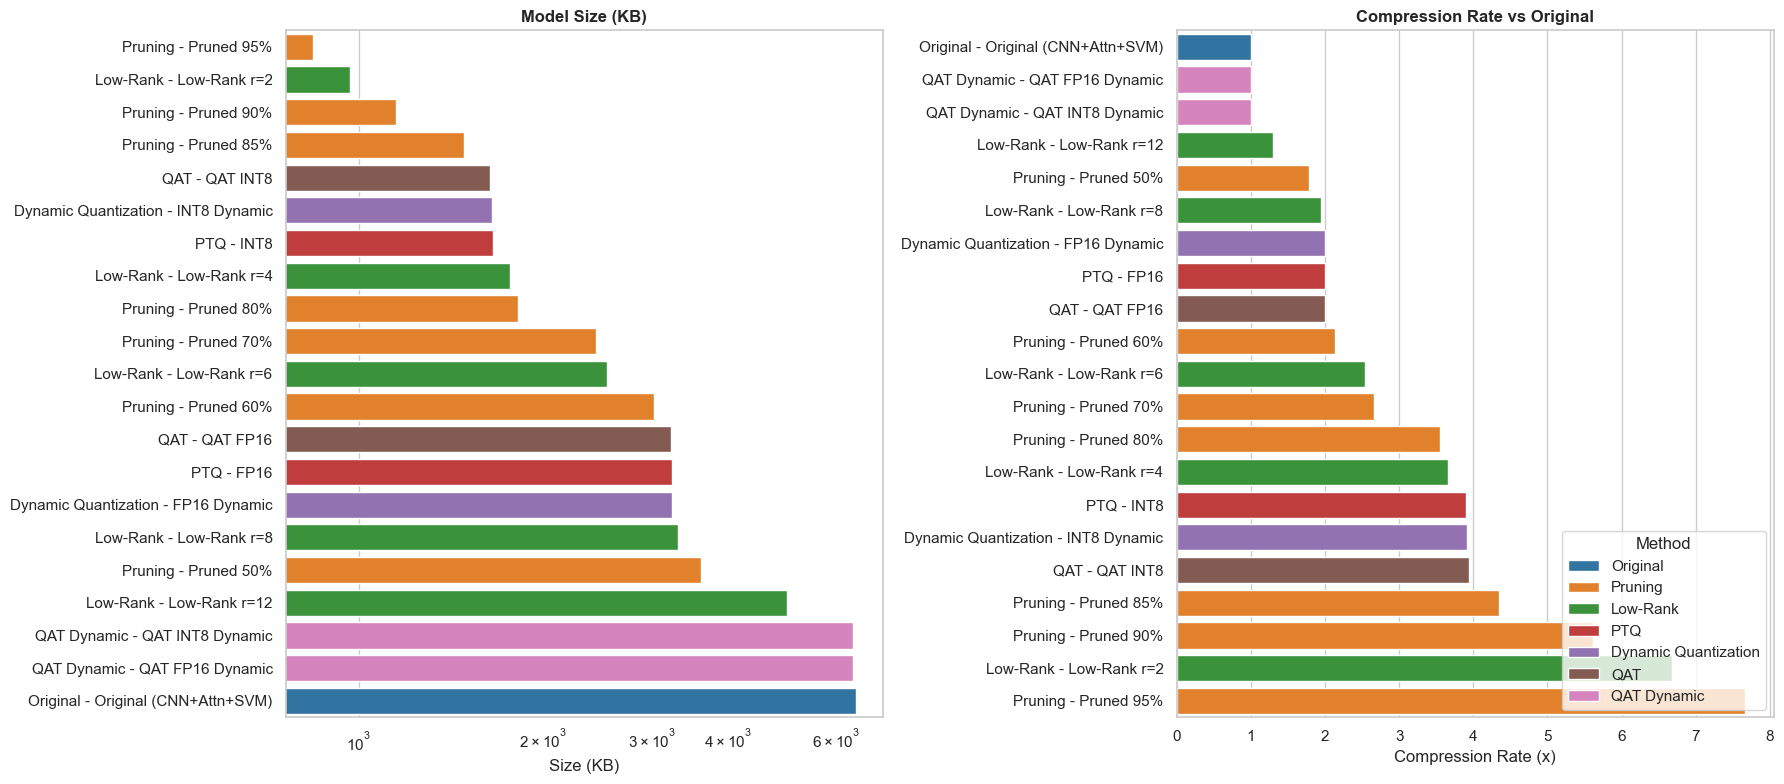

Saved: d:\bintang\skripsi 0606\comparison_all_models_20260608_213651\size_compression_plot.png


In [8]:
plot_df = df_all.copy()
plot_df["Label"] = plot_df["Method"].astype(str) + " - " + plot_df["Model"].astype(str)

# 1. Size and compression side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(plot_df) * 0.35)))

size_sorted = plot_df.sort_values("Size (KB)", ascending=True)
sns.barplot(data=size_sorted, y="Label", x="Size (KB)", hue="Method", dodge=False, ax=axes[0], palette="tab10")
axes[0].set_title("Model Size (KB)", fontweight="bold")
axes[0].set_xlabel("Size (KB)")
axes[0].set_ylabel("")
axes[0].set_xscale("log")
axes[0].legend_.remove()

comp_sorted = plot_df.sort_values("Compression Rate", ascending=True)
sns.barplot(data=comp_sorted, y="Label", x="Compression Rate", hue="Method", dodge=False, ax=axes[1], palette="tab10")
axes[1].set_title("Compression Rate vs Original", fontweight="bold")
axes[1].set_xlabel("Compression Rate (x)")
axes[1].set_ylabel("")
axes[1].legend(title="Method", loc="lower right")

plt.tight_layout()
size_plot_path = OUTPUT_DIR / "size_compression_plot.png"
plt.savefig(size_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {size_plot_path}")


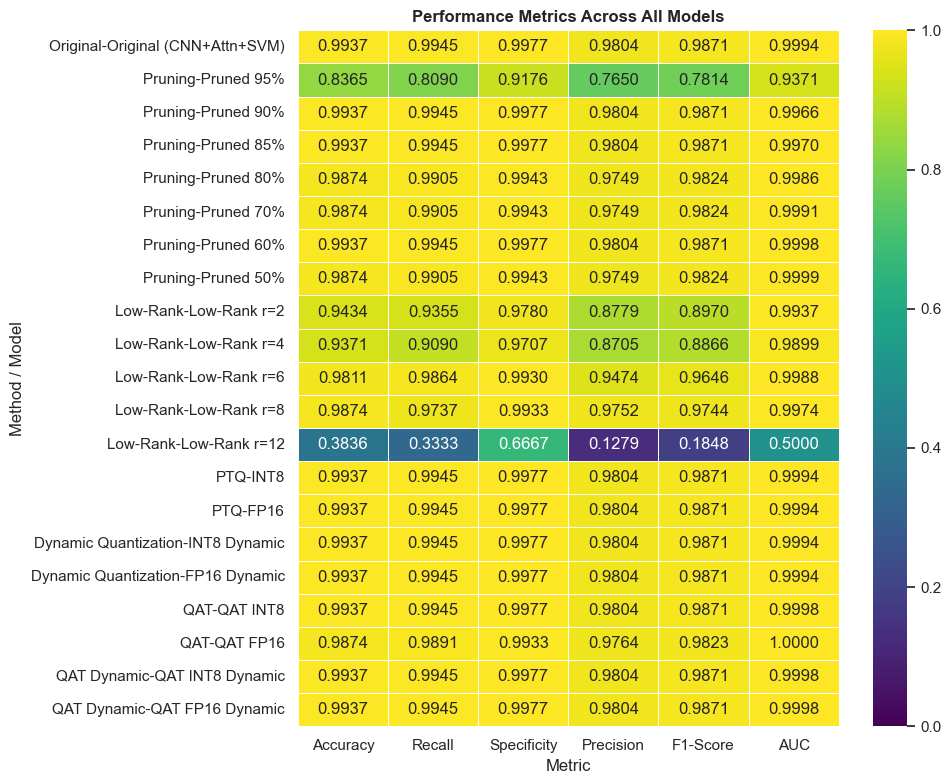

Saved: d:\bintang\skripsi 0606\comparison_all_models_20260608_213651\metrics_comparison_plot.png


In [9]:
# 2. Metrics comparison heatmap.
metrics_matrix = df_all.set_index(["Method", "Model"])[metric_cols]

fig, ax = plt.subplots(figsize=(10, max(8, len(metrics_matrix) * 0.35)))
sns.heatmap(metrics_matrix, annot=True, fmt=".4f", cmap="viridis", vmin=0, vmax=1, linewidths=0.4, ax=ax)
ax.set_title("Performance Metrics Across All Models", fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("Method / Model")
plt.tight_layout()
metrics_plot_path = OUTPUT_DIR / "metrics_comparison_plot.png"
plt.savefig(metrics_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {metrics_plot_path}")


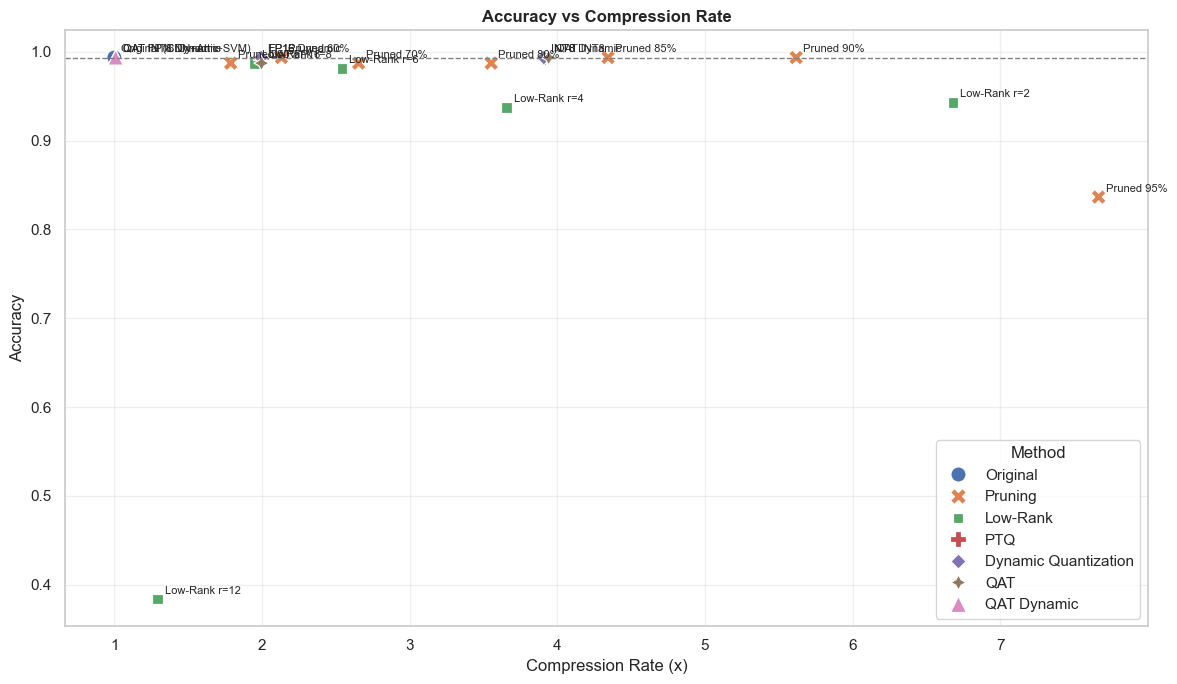

Saved: d:\bintang\skripsi 0606\comparison_all_models_20260608_213651\accuracy_vs_compression_plot.png


In [10]:
# 3. Accuracy vs compression trade-off.
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=plot_df,
    x="Compression Rate",
    y="Accuracy",
    hue="Method",
    style="Method",
    s=120,
    ax=ax,
)

for _, row in plot_df.iterrows():
    ax.annotate(row["Model"], (row["Compression Rate"], row["Accuracy"]), xytext=(5, 4), textcoords="offset points", fontsize=8)

ax.axhline(df_all.loc[df_all["Method"] == "Original", "Accuracy"].iloc[0], color="gray", linestyle="--", linewidth=1, label="Original Accuracy")
ax.set_title("Accuracy vs Compression Rate", fontweight="bold")
ax.set_xlabel("Compression Rate (x)")
ax.set_ylabel("Accuracy")
ax.grid(alpha=0.3)
plt.tight_layout()
tradeoff_plot_path = OUTPUT_DIR / "accuracy_vs_compression_plot.png"
plt.savefig(tradeoff_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {tradeoff_plot_path}")


## Ranking Views


In [11]:
print("Top 10 by Compression Rate")
display(df_all.sort_values("Compression Rate", ascending=False)[display_cols].head(10))

print("Top 10 by Accuracy, then Compression Rate")
display(df_all.sort_values(["Accuracy", "Compression Rate"], ascending=[False, False])[display_cols].head(10))


Top 10 by Compression Rate


,Method,Model,Size (KB),Compression Rate,Accuracy,Recall,Specificity,Precision,F1-Score,AUC
1,Pruning,Pruned 95%,841.950000,7.666375,0.8365,0.8090,0.9176,0.7650,0.7814,0.9371
8,Low-Rank,Low-Rank r=2,966.204102,6.680477,0.9434,0.9355,0.9780,0.8779,0.8970,0.9937
2,Pruning,Pruned 90%,1148.950000,5.617916,0.9937,0.9945,0.9977,0.9804,0.9871,0.9966
3,Pruning,Pruned 85%,1485.940000,4.343852,0.9937,0.9945,0.9977,0.9804,0.9871,0.9970
17,QAT,QAT INT8,1637.564453,3.941649,0.9937,0.9945,0.9977,0.9804,0.9871,0.9998
15,Dynamic Quantization,INT8 Dynamic,1651.330078,3.908791,0.9937,0.9945,0.9977,0.9804,0.9871,0.9994
13,PTQ,INT8,1651.978516,3.907257,0.9937,0.9945,0.9977,0.9804,0.9871,0.9994
9,Low-Rank,Low-Rank r=4,1765.219727,3.656601,0.9371,0.9090,0.9707,0.8705,0.8866,0.9899
4,Pruning,Pruned 80%,1817.080000,3.552240,0.9874,0.9905,0.9943,0.9749,0.9824,0.9986
5,Pruning,Pruned 70%,2431.160000,2.654989,0.9874,0.9905,0.9943,0.9749,0.9824,0.9991


Top 10 by Accuracy, then Compression Rate


,Method,Model,Size (KB),Compression Rate,Accuracy,Recall,Specificity,Precision,F1-Score,AUC
0,Original,Original (CNN+Attn+SVM),6454.704102,1.000000,0.993711,0.994536,0.997669,0.980392,0.987144,0.999396
2,Pruning,Pruned 90%,1148.950000,5.617916,0.993700,0.994500,0.997700,0.980400,0.987100,0.996600
3,Pruning,Pruned 85%,1485.940000,4.343852,0.993700,0.994500,0.997700,0.980400,0.987100,0.997000
17,QAT,QAT INT8,1637.564453,3.941649,0.993700,0.994500,0.997700,0.980400,0.987100,0.999800
15,Dynamic Quantization,INT8 Dynamic,1651.330078,3.908791,0.993700,0.994500,0.997700,0.980400,0.987100,0.999400
13,PTQ,INT8,1651.978516,3.907257,0.993700,0.994500,0.997700,0.980400,0.987100,0.999400
6,Pruning,Pruned 60%,3027.800000,2.131813,0.993700,0.994500,0.997700,0.980400,0.987100,0.999800
14,PTQ,FP16,3237.154297,1.993944,0.993700,0.994500,0.997700,0.980400,0.987100,0.999400
16,Dynamic Quantization,FP16 Dynamic,3237.154297,1.993944,0.993700,0.994500,0.997700,0.980400,0.987100,0.999400
19,QAT Dynamic,QAT INT8 Dynamic,6397.369141,1.008962,0.993700,0.994500,0.997700,0.980400,0.987100,0.999800


## Notes

- `Compression Rate` dihitung ulang dari baseline original untuk membuat semua metode dapat dibandingkan pada satu acuan.
- Pruning menggunakan GZIP size karena manfaat pruning terhadap ukuran file terjadi saat weight sparse dikompresi; file `.gz` tidak ada di folder saved, jadi nilai GZIP diambil dari tabel hasil pruning yang sudah dihitung notebook pruning.
- Notebook ini tidak melakukan retraining atau inference ulang; metrik performa tetap berasal dari eksperimen masing-masing folder.
